# Imports

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Data Ingestion

## Read Data

In [2]:
# from google.colab import files
# uploaded = files.upload()

In [3]:

import os
from pyspark.sql import SparkSession

# os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
# os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"
# os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("DemandForecastingPipeline")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.ui.enabled", "false")
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.6")
    .config("spark.hadoop.fs.s3a.endpoint", "http://127.0.0.1:9000")
    .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
    .config("spark.hadoop.fs.s3a.secret.key", "minioadmin")
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")
    .config("spark.hadoop.fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider")
    .config("spark.hadoop.fs.s3a.fast.upload", "true")
    .config("spark.hadoop.fs.s3a.fast.upload.buffer", "bytebuffer")
    .config("spark.hadoop.fs.s3a.buffer.dir", "C:/temp/s3a")
    .getOrCreate()
)



file_path = "demand_forecasting.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)
df.show(5)


+----------+--------+----------+-----------+------+---------------+----------+-------------+-----+--------+-----------------+---------+------------------+-----------+--------+------+
|      Date|Store ID|Product ID|   Category|Region|Inventory Level|Units Sold|Units Ordered|Price|Discount|Weather Condition|Promotion|Competitor Pricing|Seasonality|Epidemic|Demand|
+----------+--------+----------+-----------+------+---------------+----------+-------------+-----+--------+-----------------+---------+------------------+-----------+--------+------+
|2022-01-01|    S001|     P0001|Electronics| North|            195|       102|          252|72.72|       5|            Snowy|        0|             85.73|     Winter|       0|   115|
|2022-01-01|    S001|     P0002|   Clothing| North|            117|       117|          249|80.16|      15|            Snowy|        1|             92.02|     Winter|       0|   229|
|2022-01-01|    S001|     P0003|   Clothing| North|            247|       114|       

In [4]:
df.printSchema()

print("Number of rows in the DataFrame:", df.count())
print("Number of columns in the DataFrame:", len(df.columns))

root
 |-- Date: date (nullable = true)
 |-- Store ID: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Inventory Level: integer (nullable = true)
 |-- Units Sold: integer (nullable = true)
 |-- Units Ordered: integer (nullable = true)
 |-- Price: double (nullable = true)
 |-- Discount: integer (nullable = true)
 |-- Weather Condition: string (nullable = true)
 |-- Promotion: integer (nullable = true)
 |-- Competitor Pricing: double (nullable = true)
 |-- Seasonality: string (nullable = true)
 |-- Epidemic: integer (nullable = true)
 |-- Demand: integer (nullable = true)

Number of rows in the DataFrame: 76000
Number of columns in the DataFrame: 16


In [5]:
df.dtypes

[('Date', 'date'),
 ('Store ID', 'string'),
 ('Product ID', 'string'),
 ('Category', 'string'),
 ('Region', 'string'),
 ('Inventory Level', 'int'),
 ('Units Sold', 'int'),
 ('Units Ordered', 'int'),
 ('Price', 'double'),
 ('Discount', 'int'),
 ('Weather Condition', 'string'),
 ('Promotion', 'int'),
 ('Competitor Pricing', 'double'),
 ('Seasonality', 'string'),
 ('Epidemic', 'int'),
 ('Demand', 'int')]

## Data Cleaning & Preprocessing

In [6]:
from pyspark.sql.functions import col, to_date, isnan, when, count
from pyspark.sql.types import DoubleType, FloatType

# 1. Cast the Date column from String to DateType
df = df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))

# 2. Check for missing (null) values across all columns
print("Checking for null values in each column:")

null_checks = []
for c in df.columns:
    col_type = df.schema[c].dataType
    if isinstance(col_type, (DoubleType, FloatType)):
        # For floating point types, check for NaN and null
        null_checks.append(count(when(isnan(col(c)) | col(c).isNull(), c)).alias(c))
    else:
        # For other types, only check for null
        null_checks.append(count(when(col(c).isNull(), c)).alias(c))

df.select(null_checks).show()

Checking for null values in each column:
+----+--------+----------+--------+------+---------------+----------+-------------+-----+--------+-----------------+---------+------------------+-----------+--------+------+
|Date|Store ID|Product ID|Category|Region|Inventory Level|Units Sold|Units Ordered|Price|Discount|Weather Condition|Promotion|Competitor Pricing|Seasonality|Epidemic|Demand|
+----+--------+----------+--------+------+---------------+----------+-------------+-----+--------+-----------------+---------+------------------+-----------+--------+------+
|   0|       0|         0|       0|     0|              0|         0|            0|    0|       0|                0|        0|                 0|          0|       0|     0|
+----+--------+----------+--------+------+---------------+----------+-------------+-----+--------+-----------------+---------+------------------+-----------+--------+------+



In [7]:
print("Checking for duplicate rows:")
initial_row_count = df.count()
distinct_row_count = df.distinct().count()

if initial_row_count == distinct_row_count:
    print("No duplicate rows found.")
else:
    num_duplicates = initial_row_count - distinct_row_count
    print(f"Found {num_duplicates} duplicate rows.")
    print("Displaying some duplicate rows if any:")
    df.groupBy(df.columns).count().filter("count > 1").show()

Checking for duplicate rows:
No duplicate rows found.


In [8]:
from pyspark.sql.functions import year, month, dayofweek

# Extract Year, Month, and Day of Week from the Date column
df_processed = df.withColumn("Year", year(col("Date"))) \
                 .withColumn("Month", month(col("Date"))) \
                 .withColumn("Day", dayofweek(col("Date")))

print("Schema after extracting time features:")
df_processed.printSchema()

Schema after extracting time features:
root
 |-- Date: date (nullable = true)
 |-- Store ID: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Inventory Level: integer (nullable = true)
 |-- Units Sold: integer (nullable = true)
 |-- Units Ordered: integer (nullable = true)
 |-- Price: double (nullable = true)
 |-- Discount: integer (nullable = true)
 |-- Weather Condition: string (nullable = true)
 |-- Promotion: integer (nullable = true)
 |-- Competitor Pricing: double (nullable = true)
 |-- Seasonality: string (nullable = true)
 |-- Epidemic: integer (nullable = true)
 |-- Demand: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)



In [9]:
# Drop the specified columns
columns_to_drop = ["Date", "Store ID", "Product ID"]
df_processed = df_processed.drop(*columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print("New schema:")
df_processed.printSchema()

Dropped columns: ['Date', 'Store ID', 'Product ID']
New schema:
root
 |-- Category: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Inventory Level: integer (nullable = true)
 |-- Units Sold: integer (nullable = true)
 |-- Units Ordered: integer (nullable = true)
 |-- Price: double (nullable = true)
 |-- Discount: integer (nullable = true)
 |-- Weather Condition: string (nullable = true)
 |-- Promotion: integer (nullable = true)
 |-- Competitor Pricing: double (nullable = true)
 |-- Seasonality: string (nullable = true)
 |-- Epidemic: integer (nullable = true)
 |-- Demand: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)



In [10]:
df_processed.show()

+-----------+------+---------------+----------+-------------+------+--------+-----------------+---------+------------------+-----------+--------+------+----+-----+---+
|   Category|Region|Inventory Level|Units Sold|Units Ordered| Price|Discount|Weather Condition|Promotion|Competitor Pricing|Seasonality|Epidemic|Demand|Year|Month|Day|
+-----------+------+---------------+----------+-------------+------+--------+-----------------+---------+------------------+-----------+--------+------+----+-----+---+
|Electronics| North|            195|       102|          252| 72.72|       5|            Snowy|        0|             85.73|     Winter|       0|   115|2022|    1|  7|
|   Clothing| North|            117|       117|          249| 80.16|      15|            Snowy|        1|             92.02|     Winter|       0|   229|2022|    1|  7|
|   Clothing| North|            247|       114|          612| 62.94|      10|            Snowy|        1|             60.08|     Winter|       0|   157|2022|   

In [11]:
df_processed.describe().show()

+-------+--------+------+------------------+-----------------+-----------------+------------------+-----------------+-----------------+-------------------+------------------+-----------+-------------------+------------------+------------------+-----------------+------------------+
|summary|Category|Region|   Inventory Level|       Units Sold|    Units Ordered|             Price|         Discount|Weather Condition|          Promotion|Competitor Pricing|Seasonality|           Epidemic|            Demand|              Year|            Month|               Day|
+-------+--------+------+------------------+-----------------+-----------------+------------------+-----------------+-----------------+-------------------+------------------+-----------+-------------------+------------------+------------------+-----------------+------------------+
|  count|   76000| 76000|             76000|            76000|            76000|             76000|            76000|            76000|              76000

### Distribution Check

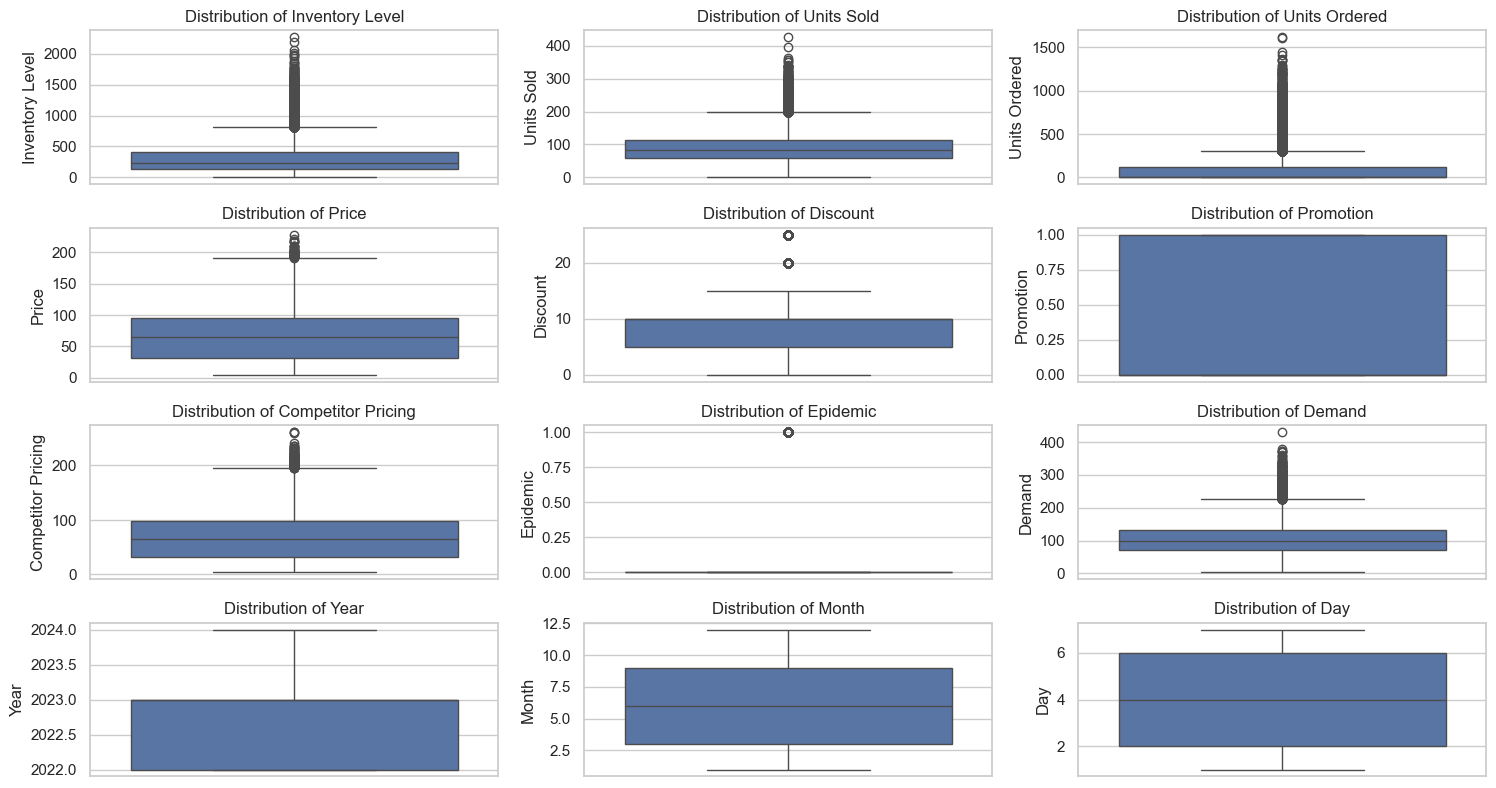

In [12]:
# Identify numeric columns (int, double, float)
numeric_cols = [f.name for f in df_processed.schema.fields if str(f.dataType).startswith(('IntegerType', 'DoubleType', 'LongType', 'FloatType'))]

# Convert a sample to Pandas for visualization (if the dataset is huge, consider taking a sample)
pdf = df_processed.select(numeric_cols).toPandas()

# Set up the plotting area
plt.figure(figsize=(15, 10))
sns.set_theme(style="whitegrid")

# Create a boxplot for each numeric column
for i, col_name in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)// 3 + 1, 3, i)
    sns.boxplot(y=pdf[col_name])
    plt.title(f'Distribution of {col_name}')

plt.tight_layout()
plt.show()

### Applying IQR filtering

In [13]:
# print(f"Applying IQR filtering to: {non_binary_cols}")

# for col_name in non_binary_cols:
#     # Calculate Q1, Q3 and IQR
#     quantiles = df_processed.approxQuantile(col_name, [0.25, 0.75], 0.05)
#     q1, q3 = quantiles[0], quantiles[1]
#     iqr = q3 - q1

#     lower_bound = q1 - 1.5 * iqr
#     upper_bound = q3 + 1.5 * iqr

#     # Filter OUT the rows that are outside the bounds
#     df_processed = df_processed.filter(
#         (col(col_name) >= lower_bound) & (col(col_name) <= upper_bound)
#     )

# print("Outlier rows dropped.")
# print(f"New row count: {df_processed.count()}")

In [14]:
# @title
# numeric_cols = [f.name for f in df_processed.schema.fields if str(f.dataType).startswith(('IntegerType', 'DoubleType', 'LongType', 'FloatType'))]

# # Convert a sample to Pandas for visualization
# pdf_after = df_processed.select(numeric_cols).toPandas()

# # Set up the plotting area
# plt.figure(figsize=(15, 10))
# sns.set_theme(style="whitegrid")

# # Create a boxplot for each numeric column to verify capping
# for i, col_name in enumerate(numeric_cols, 1):
#     plt.subplot((len(numeric_cols) + 2) // 3, 3, i)
#     sns.boxplot(y=pdf_after[col_name])
#     plt.title(f'Post-Capping: {col_name}')

# plt.tight_layout()
# plt.show()

## Distributed Storage (Recommended: MinIO with Docker Compose)

    For this project, **MinIO** is the easier choice compared with HDFS because it is lightweight, Docker-friendly, and Spark can use it through the `s3a://` connector. HDFS is still a valid alternative, but it is heavier to install for a single-machine class project.

    Recommended local MinIO startup uses the included `docker-compose.yml` file:

    ```bash
    docker compose up -d
    ```

    This starts MinIO from the project-level `docker-compose.yml` file with:

    - API endpoint on port `9000`
    - Web console on port `9001`
    - Default credentials `minioadmin / minioadmin`
    - A persistent Docker volume named `minio_data`

    To stop it later:

    ```bash
    docker compose down
    ```

    Then open [http://localhost:9001](http://localhost:9001), log in with `minioadmin / minioadmin`.

    The next code cell writes the cleaned dataset directly to **MinIO** using the `s3a://cleaned-data/...` path.

    Important note: after changing the Spark session configuration, you must **restart the notebook kernel and run all cells again from the top** so Spark starts with the S3A connector enabled.


**Create 3 buckets: demand-lake, cleaned-data, backup-data**

In [15]:
import re

hconf = spark.sparkContext._jsc.hadoopConfiguration()
hconf.set("fs.s3a.vectored.reads.enabled", "false")

def _normalize_s3a_duration(value: str) -> str | None:
    match = re.match(r"^(\d+)(ms|s|m|h|d)$", value.strip())
    if not match:
        return None
    number = int(match.group(1))
    unit = match.group(2)
    multipliers = {"ms": 1, "s": 1000, "m": 60000, "h": 3600000, "d": 86400000}
    return str(number * multipliers[unit])

it = hconf.iterator()
while it.hasNext():
    entry = it.next()
    key = entry.getKey()
    value = entry.getValue()
    if key.startswith("fs.s3a.") and isinstance(value, str):
        normalized = _normalize_s3a_duration(value)
        if normalized is not None:
            hconf.set(key, normalized)

minio_path = "s3a://cleaned-data/cleaned-demand/"

(
    df_processed
    .repartition("Region", "Seasonality")
    .write
    .mode("overwrite")
    .partitionBy("Region", "Seasonality")
    .parquet(minio_path)
)

print(f"Cleaned dataset saved to MinIO as partitioned parquet: {minio_path}")
print("Current Spark partitions:", df_processed.rdd.getNumPartitions())


Cleaned dataset saved to MinIO as partitioned parquet: s3a://cleaned-data/cleaned-demand/
Current Spark partitions: 2


# 2. Data Analyst (Exploration & Insights)

## EDA

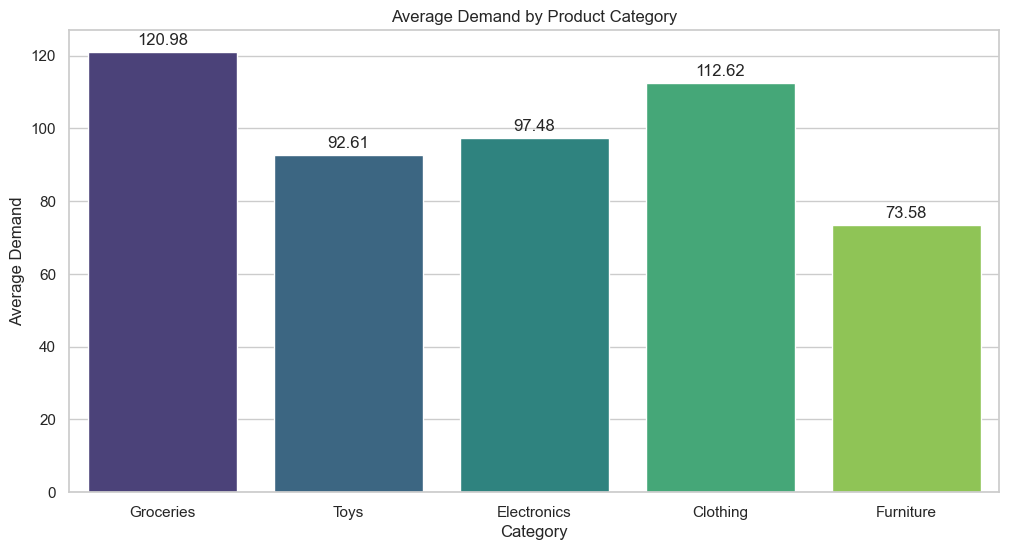

In [16]:
# 1. Demand Trends by Category
plt.figure(figsize=(12, 6))
category_demand = df_processed.groupBy('Category').avg('Demand').toPandas()

ax = sns.barplot(data=category_demand, x='Category', y='avg(Demand)', palette='viridis', hue='Category', legend=False)

# Add the exact value at the top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Average Demand by Product Category')
plt.ylabel('Average Demand')
plt.show()


1. **Category Performance**: Groceries category (e.g., Groceries, Clothing) may show significantly higher average demand, suggesting they are primary drivers of volume.

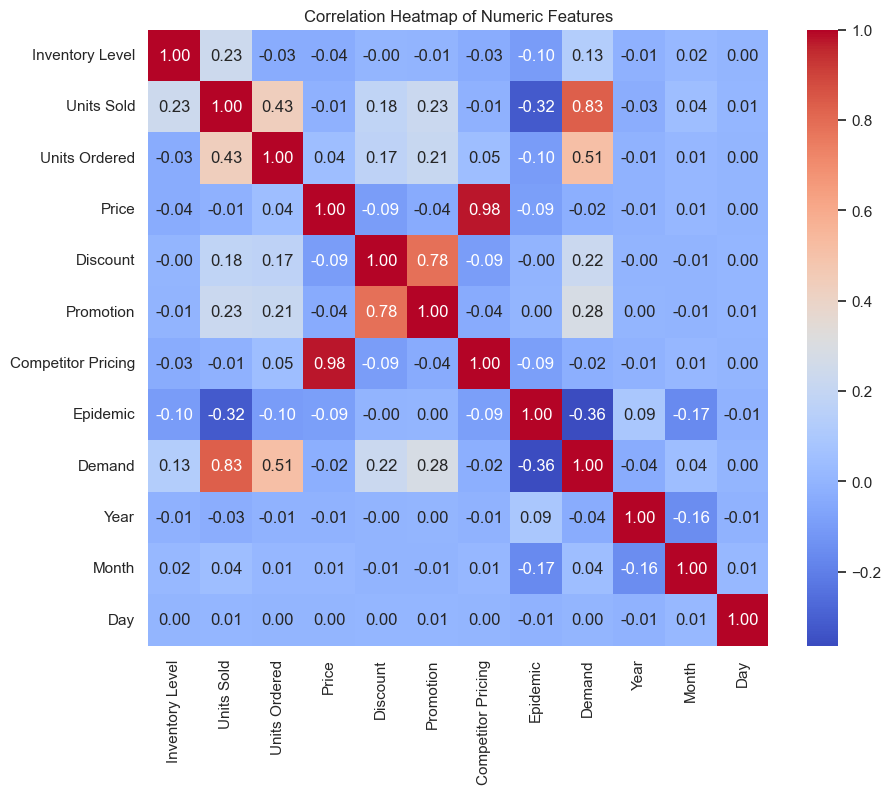

In [17]:
# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_pdf = df_processed.select([c for c, t in df_processed.dtypes if t in ['int', 'double']]).toPandas()
corr = numeric_pdf.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

2. **Correlation Analysis**: The heatmap reveals how strongly features like `Units Sold`, `Units Ordered`, or `Epidemic` correlate with `Demand`.

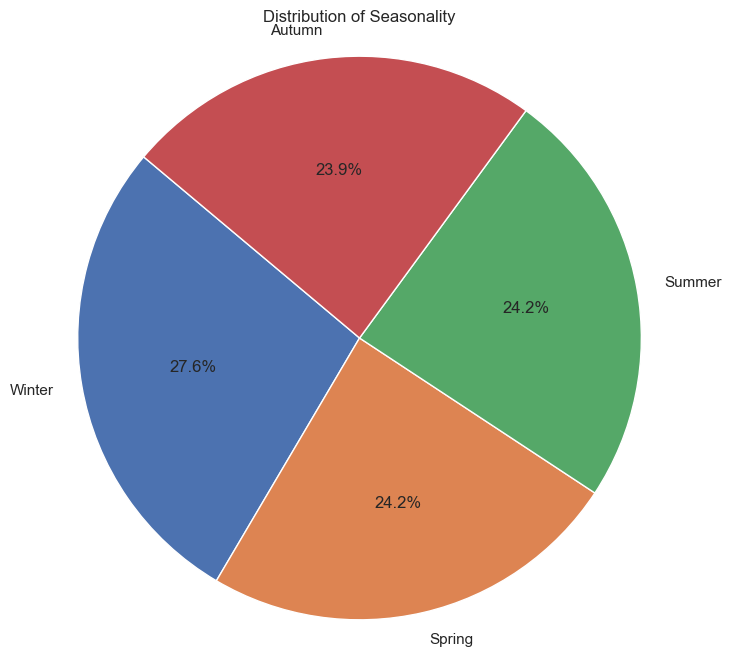

In [18]:
# Count the occurrences of each seasonality
seasonality_counts = df_processed.groupBy('Seasonality').count().toPandas()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(seasonality_counts['count'], labels=seasonality_counts['Seasonality'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Seasonality')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

3. ** Pie Chart**: We can see that the `Winter` has higher frequency but also the other seasons are close

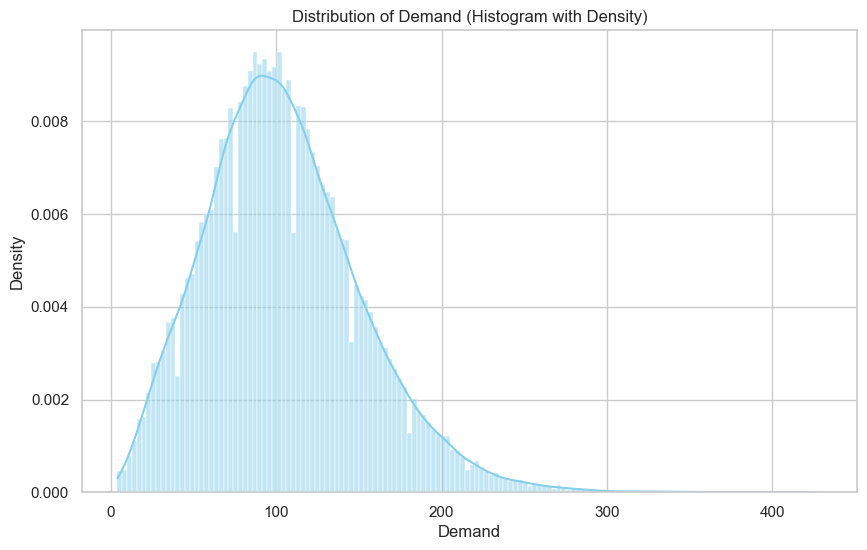

In [19]:
# Convert Demand column to pandas for plotting
demand_data = df_processed.select('Demand').toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(demand_data['Demand'], kde=True, stat="density", color='skyblue')
plt.title('Distribution of Demand (Histogram with Density)')
plt.xlabel('Demand')
plt.ylabel('Density')
plt.show()

4. **Right-Skewed Distribution Histogram**: The distribution is not perfectly symmetrical; it has a longer tail on the right side.

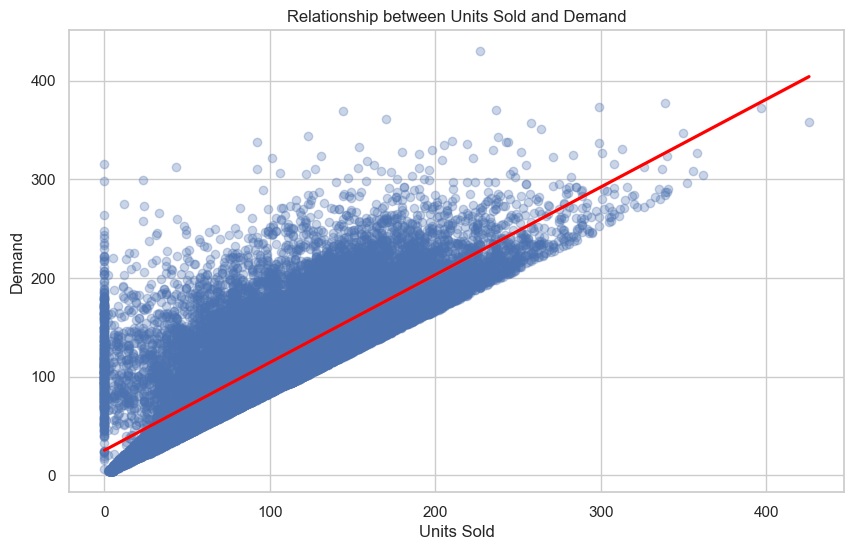

In [20]:
# Sampling for performance if data is large, though 76k is manageable for regplot
pdf_plot = df_processed.select(['Units Sold', 'Demand']).toPandas()

plt.figure(figsize=(10, 6))
sns.regplot(data=pdf_plot, x='Units Sold', y='Demand', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Units Sold and Demand')
plt.xlabel('Units Sold')
plt.ylabel('Demand')
plt.show()

5. **Scatter Plot** :Positive linear relationship,This indicates that as "Units Sold" increases on the x-axis, "Demand" increases at a constant, proportional rate on the y-axis.

### Regional Sales Analysis


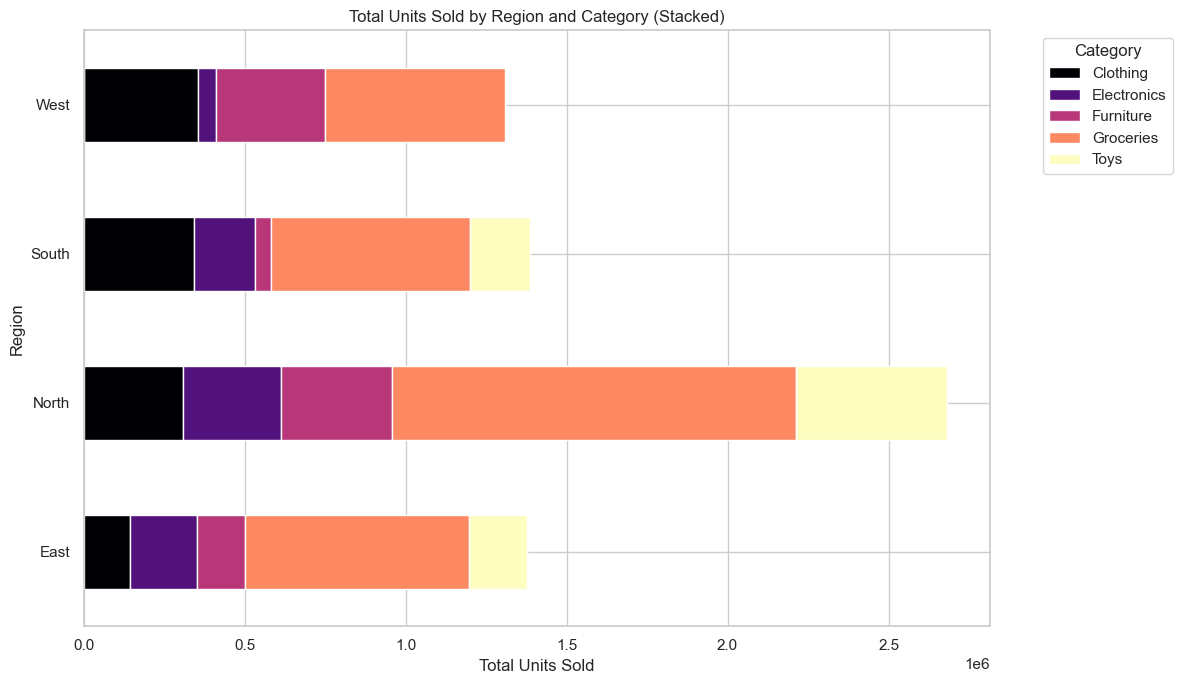

In [21]:
# Aggregate Units Sold by Region and Category
stacked_data = df_processed.groupBy('Region', 'Category').sum('Units Sold').toPandas()

# Pivot the data to create a stacked structure
pivot_df = stacked_data.pivot(index='Region', columns='Category', values='sum(Units Sold)')

# Create a horizontal stacked bar chart
ax = pivot_df.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='magma')

plt.title('Total Units Sold by Region and Category (Stacked)')
plt.xlabel('Total Units Sold')
plt.ylabel('Region')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6.Stacked Bar Chart:

1.  **Dominant Region**: The **North** region has the highest total volume of units sold, nearly doubling the output of the other individual regions.
2.  **Category Leader**: **Groceries** is the primary driver of sales across all regions, consistently representing the largest segment in each bar.
3.  **Regional Strengths**:
    *   The **West** region shows a strong presence in **Furniture** compared to others.
    *   The **South** has a notable contribution from **Clothing**.

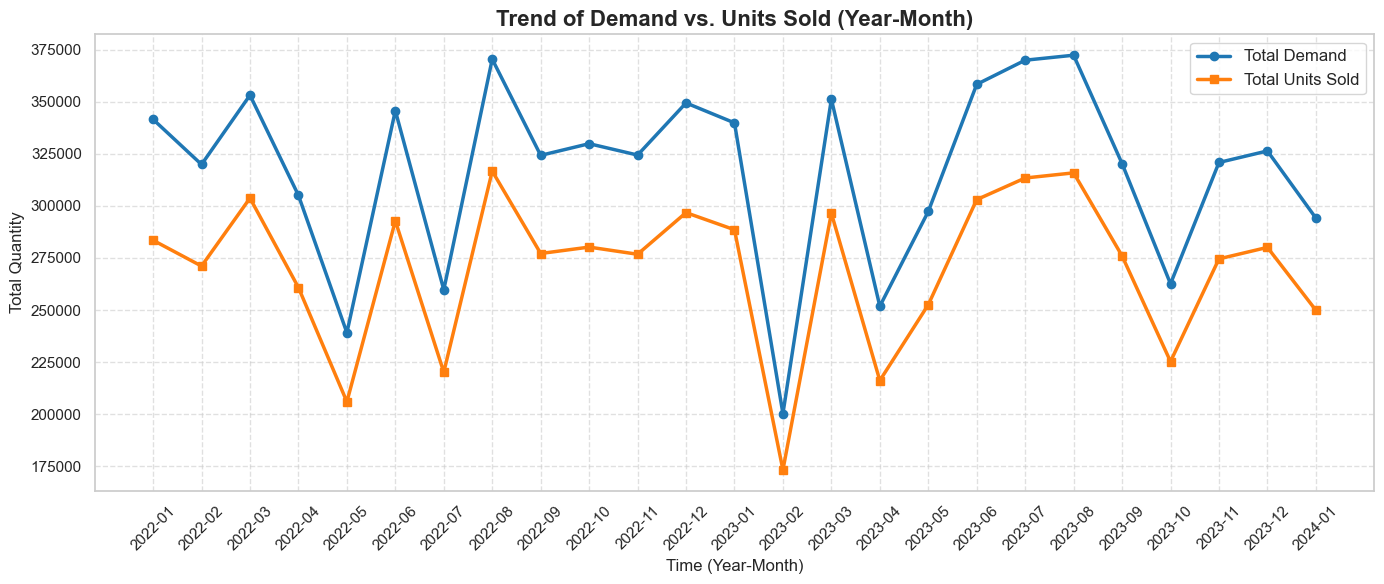

In [22]:
from pyspark.sql.functions import sum

# 1. Aggregate the data using PySpark
# We group by both Year and Month and calculate the sum for both metrics
time_trend_df = df_processed.groupBy("Year", "Month") \
    .agg(
        sum("Demand").alias("Total_Demand"),
        sum("Units Sold").alias("Total_Units_Sold")
    ) \
    .orderBy("Year", "Month")

# 2. Convert the small aggregated summary to Pandas for plotting
trend_pd = time_trend_df.toPandas()

# 3. Create a combined "Year-Month" string column for a clean X-axis
trend_pd['Year-Month'] = trend_pd['Year'].astype(str) + '-' + trend_pd['Month'].astype(str).str.zfill(2)

# 4. Generate the overlaid line plot
plt.figure(figsize=(14, 6))

# Plot the Demand line (Blue circles)
plt.plot(trend_pd['Year-Month'], trend_pd['Total_Demand'],
         marker='o', color='#1f77b4', linewidth=2.5, label='Total Demand')

# Plot the Units Sold line (Orange squares)
plt.plot(trend_pd['Year-Month'], trend_pd['Total_Units_Sold'],
         marker='s', color='#ff7f0e', linewidth=2.5, label='Total Units Sold')

# 5. Format the chart to make it presentation-ready
plt.title("Trend of Demand vs. Units Sold (Year-Month)", fontsize=16, fontweight='bold')
plt.xlabel("Time (Year-Month)", fontsize=12)
plt.ylabel("Total Quantity", fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels so they don't overlap
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()

7. **Line Plot** : Gap between demand and sales,This indicates that "Total Demand" consistently tracks higher than actual "Units Sold" over time, highlighting periods of unfulfilled demand likely caused by inventory shortages or stockouts.

# 3. Machine Learning Engineer (Model Development)


## Feature Engineering

        The model section keeps the original `Date` and `Product ID` columns so we can build time-aware features such as lag demand and rolling demand averages. This is more suitable for forecasting than relying only on static tabular features.


In [23]:
from pyspark.sql import Window
from pyspark.sql.functions import (
    avg,
    col,
    dayofweek,
    lag,
    month,
    row_number,
    to_date,
    when,
    year,
)

df_model_base = df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))

product_window = Window.partitionBy("Product ID").orderBy("Date")
rolling_7_window = product_window.rowsBetween(-7, -1)

df_features = (
    df_model_base
    .withColumn("Year", year(col("Date")))
    .withColumn("Month", month(col("Date")))
    .withColumn("DayOfWeek", dayofweek(col("Date")))
    .withColumn("lag_1_demand", lag("Demand", 1).over(product_window))
    .withColumn("lag_7_demand", lag("Demand", 7).over(product_window))
    .withColumn("rolling_7_avg_demand", avg("Demand").over(rolling_7_window))
    .withColumn(
        "inventory_gap",
        col("Inventory Level") - col("Demand")
    )
    .withColumn(
        "price_gap",
        col("Price") - col("Competitor Pricing")
    )
    .withColumn(
        "sell_through_ratio",
        when(col("Inventory Level") > 0, col("Units Sold") / col("Inventory Level")).otherwise(0.0)
    )
    .withColumn(
        "order_fill_ratio",
        when(col("Units Ordered") > 0, col("Units Sold") / col("Units Ordered")).otherwise(0.0)
    )
)

df_features = df_features.dropna(subset=["lag_1_demand", "lag_7_demand", "rolling_7_avg_demand"])

print("Feature-engineered dataset shape:", df_features.count(), "rows and", len(df_features.columns), "columns")
df_features.select(
    "Date",
    "Product ID",
    "Demand",
    "lag_1_demand",
    "lag_7_demand",
    "rolling_7_avg_demand",
    "inventory_gap",
    "price_gap",
).show(5, truncate=False)


Feature-engineered dataset shape: 75860 rows and 26 columns
+----------+----------+------+------------+------------+--------------------+-------------+-------------------+
|Date      |Product ID|Demand|lag_1_demand|lag_7_demand|rolling_7_avg_demand|inventory_gap|price_gap          |
+----------+----------+------+------------+------------+--------------------+-------------+-------------------+
|2022-01-02|P0001     |91    |137         |115         |104.42857142857143  |-18          |-1.049999999999999 |
|2022-01-02|P0001     |160   |91          |118         |101.0               |-30          |0.7200000000000006 |
|2022-01-02|P0001     |75    |160         |112         |107.0               |32           |1.6399999999999988 |
|2022-01-03|P0001     |132   |75          |81          |101.71428571428571  |142          |-12.180000000000007|
|2022-01-03|P0001     |189   |132         |84          |109.0               |-189         |-8.010000000000005 |
+----------+----------+------+------------+-

In [24]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler

ordered_dates = [row["Date"] for row in df_features.select("Date").distinct().orderBy("Date").collect()]
split_index = int(len(ordered_dates) * 0.8)
split_date = ordered_dates[split_index]

train_df = df_features.filter(col("Date") < split_date)
test_df = df_features.filter(col("Date") >= split_date)

categorical_cols = ["Category", "Region", "Weather Condition", "Seasonality"]
index_cols = ["Category_idx", "Region_idx", "Weather_idx", "Seasonality_idx"]
encoded_cols = ["Category_vec", "Region_vec", "Weather_vec", "Seasonality_vec"]

numeric_feature_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Year",
    "Month",
    "DayOfWeek",
    "lag_1_demand",
    "lag_7_demand",
    "rolling_7_avg_demand",
    "inventory_gap",
    "price_gap",
    "sell_through_ratio",
    "order_fill_ratio",
]

indexers = [
    StringIndexer(inputCol=src, outputCol=dst, handleInvalid="keep")
    for src, dst in zip(categorical_cols, index_cols)
]

encoder = OneHotEncoder(inputCols=index_cols, outputCols=encoded_cols, handleInvalid="keep")
assembler = VectorAssembler(
    inputCols=numeric_feature_cols + encoded_cols,
    outputCol="features",
    handleInvalid="keep",
)

preprocessing_pipeline = Pipeline(stages=indexers + [encoder, assembler])
preprocessing_model = preprocessing_pipeline.fit(train_df)

train_ready = (
    preprocessing_model
    .transform(train_df)
    .select("Date", "Demand", "features")
    .cache()
)

test_ready = (
    preprocessing_model
    .transform(test_df)
    .select("Date", "Category", "Region", "Demand", "features")
    .cache()
)

print("Train rows:", train_ready.count())
print("Test rows:", test_ready.count())
print("Time-based split date:", split_date)


Train rows: 60660
Test rows: 15200
Time-based split date: 2023-09-01


## Model Training and Evaluation

Three PySpark regression models are compared below using lighter hyperparameters so the notebook stays stable on a local machine:

- `LinearRegression` as the main interpretable baseline
- `RandomForestRegressor` with a smaller tree count and depth
- `GBTRegressor` with fewer boosting iterations


In [25]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import GBTRegressor, LinearRegression, RandomForestRegressor

# Use a smaller sampled training set for tree-based models to reduce JVM crashes on local machines.
train_tree_ready = train_ready.sample(False, 0.35, seed=42).cache()

print("Linear model training rows:", train_ready.count())
print("Tree model training rows:", train_tree_ready.count())

models = {
    "Linear Regression": (
        LinearRegression(
            featuresCol="features",
            labelCol="Demand",
            maxIter=50,
            regParam=0.1,
            elasticNetParam=0.2,
        ),
        train_ready,
    ),
    "Random Forest": (
        RandomForestRegressor(
            featuresCol="features",
            labelCol="Demand",
            numTrees=30,
            maxDepth=6,
            subsamplingRate=0.8,
            seed=42,
        ),
        train_tree_ready,
    ),
    "Gradient Boosting": (
        GBTRegressor(
            featuresCol="features",
            labelCol="Demand",
            maxIter=20,
            maxDepth=4,
            maxBins=32,
            stepSize=0.1,
            seed=42,
        ),
        train_tree_ready,
    ),
}

evaluators = {
    "RMSE": RegressionEvaluator(labelCol="Demand", predictionCol="prediction", metricName="rmse"),
    "MAE": RegressionEvaluator(labelCol="Demand", predictionCol="prediction", metricName="mae"),
    "R2": RegressionEvaluator(labelCol="Demand", predictionCol="prediction", metricName="r2"),
}

fitted_models = {}
model_predictions = {}
metrics_rows = []

for model_name, (estimator, training_df) in models.items():
    print(f"Training {model_name} ...")
    trained_model = estimator.fit(training_df)
    predictions = trained_model.transform(test_ready).cache()

    fitted_models[model_name] = trained_model
    model_predictions[model_name] = predictions

    metrics_rows.append((
        model_name,
        evaluators["RMSE"].evaluate(predictions),
        evaluators["MAE"].evaluate(predictions),
        evaluators["R2"].evaluate(predictions),
    ))

metrics_pd = pd.DataFrame(metrics_rows, columns=["Model", "RMSE", "MAE", "R2"]).sort_values("RMSE").reset_index(drop=True)
print(metrics_pd.to_string(index=False))

best_model_name = metrics_pd.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_predictions = model_predictions[best_model_name]

print(f"Best model based on RMSE: {best_model_name}")


Linear model training rows: 60660
Tree model training rows: 21255
Training Linear Regression ...
Training Random Forest ...
Training Gradient Boosting ...
            Model      RMSE       MAE       R2
Linear Regression 13.515941 10.193616 0.906010
Gradient Boosting 16.011815 12.611173 0.868093
    Random Forest 17.065201 13.374107 0.850166
Best model based on RMSE: Linear Regression


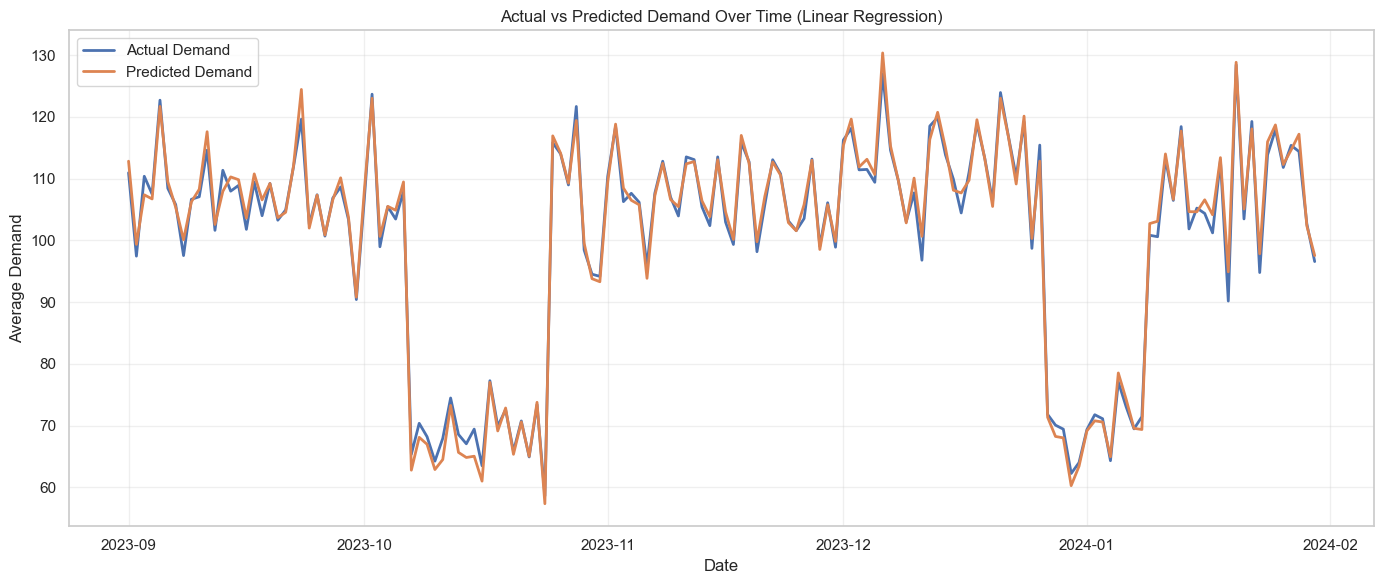

In [26]:
best_pred_daily = (
    best_predictions
    .groupBy("Date")
    .agg(
        avg("Demand").alias("avg_actual_demand"),
        avg("prediction").alias("avg_predicted_demand"),
    )
    .orderBy("Date")
    .toPandas()
)

plt.figure(figsize=(14, 6))
plt.plot(best_pred_daily["Date"], best_pred_daily["avg_actual_demand"], label="Actual Demand", linewidth=2)
plt.plot(best_pred_daily["Date"], best_pred_daily["avg_predicted_demand"], label="Predicted Demand", linewidth=2)
plt.title(f"Actual vs Predicted Demand Over Time ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Average Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Time Series Model (ARIMA)

In addition to the Spark regression models, this section trains a classical **ARIMA** model on aggregated daily demand. ARIMA is univariate, so it uses only the daily demand history rather than the full tabular feature set.


In [27]:
from statsmodels.tsa.arima.model import ARIMA

daily_demand_pd = (
    df
    .withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
    .groupBy("Date")
    .agg(sum("Demand").alias("total_demand"))
    .orderBy("Date")
    .toPandas()
)

daily_demand_pd["Date"] = pd.to_datetime(daily_demand_pd["Date"])
daily_demand_pd = daily_demand_pd.sort_values("Date").reset_index(drop=True)

split_idx = int(len(daily_demand_pd) * 0.8)
arima_train = daily_demand_pd.iloc[:split_idx].copy()
arima_test = daily_demand_pd.iloc[split_idx:].copy()

arima_model = ARIMA(arima_train["total_demand"], order=(7, 1, 2))
arima_fitted = arima_model.fit()
arima_forecast = arima_fitted.forecast(steps=len(arima_test))

arima_results_pd = arima_test.copy()
arima_results_pd["forecast"] = arima_forecast.to_numpy()

arima_rmse = float(np.sqrt(np.mean((arima_results_pd["total_demand"] - arima_results_pd["forecast"]) ** 2)))
arima_mae = float(np.mean(np.abs(arima_results_pd["total_demand"] - arima_results_pd["forecast"])))
arima_r2 = float(
    1
    - (
        ((arima_results_pd["total_demand"] - arima_results_pd["forecast"]) ** 2).sum()
        / ((arima_results_pd["total_demand"] - arima_results_pd["total_demand"].mean()) ** 2).sum()
    )
)

arima_metrics_pd = pd.DataFrame(
    [{"Model": "ARIMA(7,1,2)", "RMSE": arima_rmse, "MAE": arima_mae, "R2": arima_r2}]
)
print(arima_metrics_pd.to_string(index=False))


       Model        RMSE         MAE       R2
ARIMA(7,1,2) 2084.161681 1415.411308 -0.44152


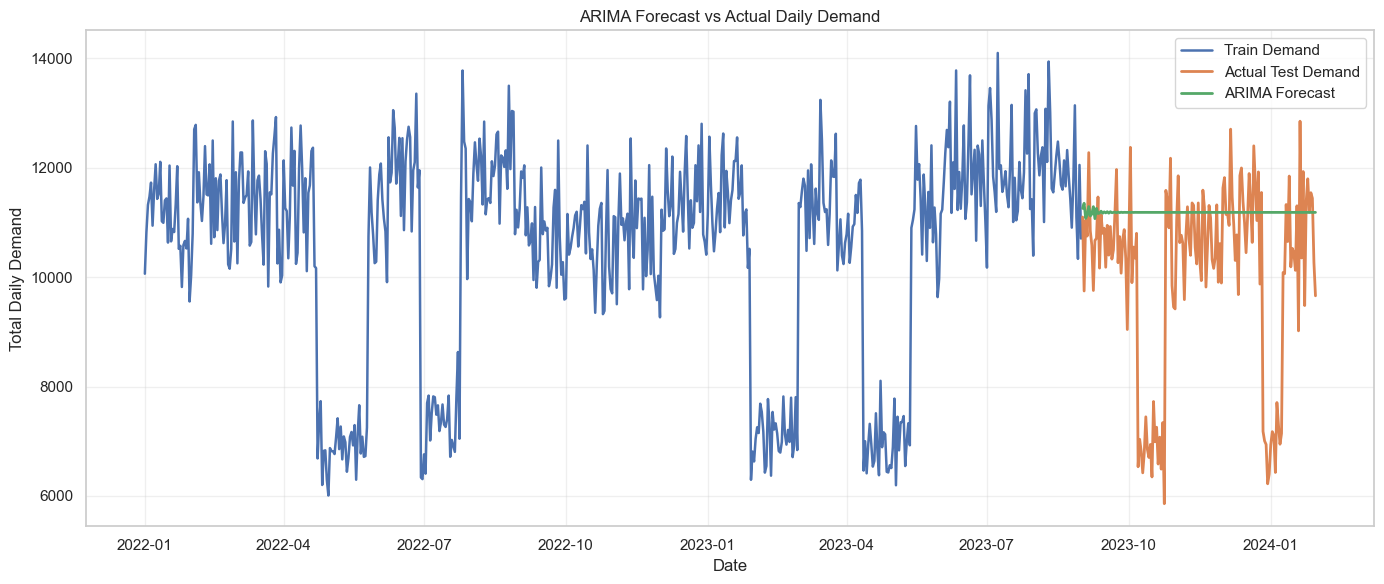

In [28]:
plt.figure(figsize=(14, 6))
plt.plot(arima_train["Date"], arima_train["total_demand"], label="Train Demand", linewidth=1.8)
plt.plot(arima_test["Date"], arima_results_pd["total_demand"], label="Actual Test Demand", linewidth=2)
plt.plot(arima_test["Date"], arima_results_pd["forecast"], label="ARIMA Forecast", linewidth=2)
plt.title("ARIMA Forecast vs Actual Daily Demand")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### ARIMA Insight

ARIMA provides a classical time-series baseline using only demand history. It is useful for comparing a pure temporal model against the feature-rich Spark regression models.


### Modeling Insights

        1. Lag and rolling-demand features improve the forecasting setup by injecting recent temporal behavior into the model.
        2. The best-performing model should be selected using RMSE first, then cross-checked with MAE and R2 for stability.
        3. The time-based split is more realistic than a random split because it avoids leaking future information into training.


# 4. Big Data Engineer (Optimization & Performance)


In [29]:
from pyspark import StorageLevel
from pyspark.sql.functions import sum

print("Partitions before optimization:", df_features.rdd.getNumPartitions())

optimized_df = (
    df_features
    .repartition(8, "Region", "Category")
    .persist(StorageLevel.MEMORY_AND_DISK)
)

print("Partitions after repartition:", optimized_df.rdd.getNumPartitions())

optimized_summary = (
    optimized_df
    .groupBy("Region", "Category")
    .agg(
        sum("Demand").alias("total_demand"),
        avg("rolling_7_avg_demand").alias("avg_recent_demand"),
    )
    .orderBy("Region", "Category")
)

optimized_summary.show(10, truncate=False)
print("Execution plan for the optimized aggregation:")
optimized_summary.explain()


Partitions before optimization: 3
Partitions after repartition: 8
+------+-----------+------------+------------------+
|Region|Category   |total_demand|avg_recent_demand |
+------+-----------+------------+------------------+
|East  |Clothing   |166222      |93.29258422736667 |
|East  |Electronics|245817      |104.44337787816046|
|East  |Furniture  |167149      |97.27266453353397 |
|East  |Groceries  |827334      |108.09770583683644|
|East  |Toys       |209637      |107.41156910722117|
|North |Clothing   |373019      |104.63322500117748|
|North |Electronics|354952      |110.29758137432206|
|North |Furniture  |391309      |97.69246293356278 |
|North |Groceries  |1466890     |106.65362615634463|
|North |Toys       |562521      |100.23271965345134|
+------+-----------+------------+------------------+
only showing top 10 rows
Execution plan for the optimized aggregation:
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [Region#21 ASC NULLS FIRST, Category#20 ASC NULLS FIRST],

In [30]:
optimized_output_path = "s3a://demand-lake/optimized-feature-store/"

(
    optimized_df
    .write
    .mode("overwrite")
    .partitionBy("Region", "Category")
    .parquet(optimized_output_path)
)

print(f"Optimized feature store written to: {optimized_output_path}")
print("Replication note: in production, replication is configured in HDFS or object storage, not inside this notebook.")


Optimized feature store written to: s3a://demand-lake/optimized-feature-store/
Replication note: in production, replication is configured in HDFS or object storage, not inside this notebook.


### Optimization Notes

        1. `repartition(8, "Region", "Category")` groups related records together and improves parallelism for aggregations and downstream writes.
        2. Persisting the engineered dataset prevents repeated recomputation during model training and evaluation.
        3. Partitioned Parquet improves read efficiency because Spark can skip irrelevant folders during scans.


### MinIO Bucket Replication (mc)

Bucket replication is configured entirely in MinIO. Enable versioning on both buckets, then add a replication rule from the source bucket to the destination bucket.

```bash
# 1) Configure mc alias for the local MinIO server
mc alias set minio http://127.0.0.1:9000 minioadmin minioadmin

# 2) Enable versioning (required for replication)
mc version enable minio/cleaned-data
mc version enable minio/backup-data

# 3) Add replication rule (source -> destination)
mc replicate add minio/cleaned-data --remote-bucket minio/backup-data

# 4) Check replication configuration and status
mc replicate ls minio/cleaned-data
mc ls minio/backup-data
```

Any new objects written to the source bucket are asynchronously copied to the destination bucket.

# 5. MLOps Engineer (Deployment & Monitoring)


In [31]:
preprocess_path = "s3a://demand-lake/models/preprocessing-pipeline/"
model_path = f"s3a://demand-lake/models/{best_model_name.lower().replace(' ', '_')}/"

preprocessing_model.write().overwrite().save(preprocess_path)
best_model.write().overwrite().save(model_path)

print("Saved preprocessing pipeline to:", preprocess_path)
print("Saved best forecasting model to:", model_path)


Saved preprocessing pipeline to: s3a://demand-lake/models/preprocessing-pipeline/
Saved best forecasting model to: s3a://demand-lake/models/linear_regression/


+-------------------+------------------------------+
|mean_absolute_error|mean_absolute_percentage_error|
+-------------------+------------------------------+
| 10.193615995329393|           0.12726816108230524|
+-------------------+------------------------------+



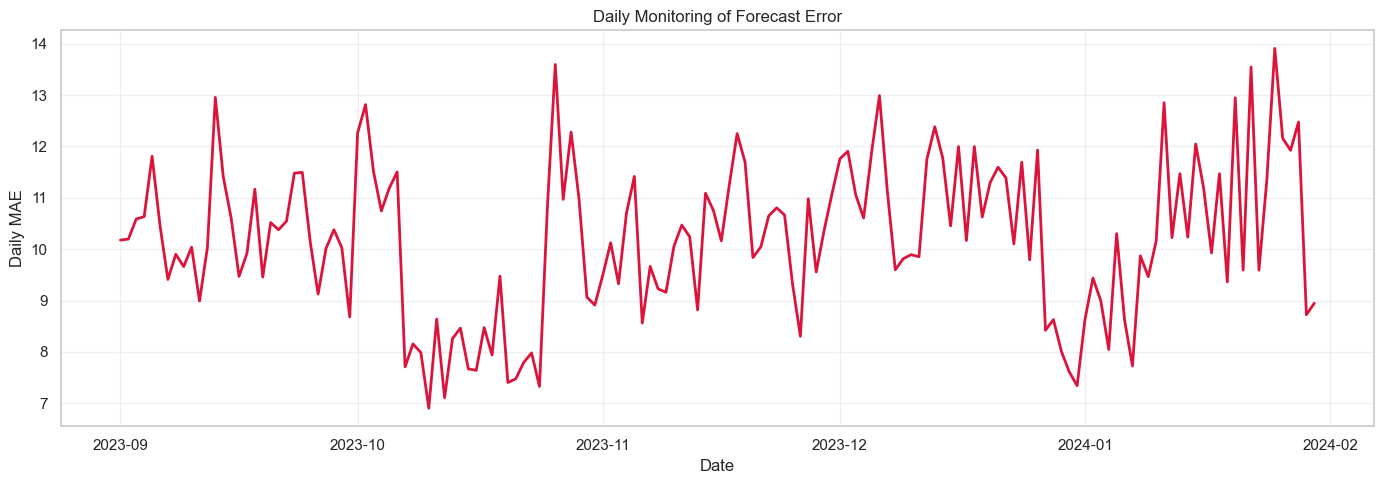

In [32]:
from pyspark.sql.functions import abs as spark_abs, lit

def run_batch_inference(input_df, preprocess_model, trained_model):
    prepared = preprocess_model.transform(input_df)
    return trained_model.transform(prepared)

monitoring_df = (
    best_predictions
    .withColumn("absolute_error", spark_abs(col("Demand") - col("prediction")))
    .withColumn(
        "absolute_percentage_error",
        when(col("Demand") != 0, spark_abs(col("Demand") - col("prediction")) / col("Demand")).otherwise(lit(0.0))
    )
)

monitoring_df.select(
    avg("absolute_error").alias("mean_absolute_error"),
    avg("absolute_percentage_error").alias("mean_absolute_percentage_error"),
).show()

daily_monitoring = (
    monitoring_df
    .groupBy("Date")
    .agg(
        avg("absolute_error").alias("daily_mae"),
        avg("Demand").alias("avg_actual_demand"),
        avg("prediction").alias("avg_predicted_demand"),
    )
    .orderBy("Date")
    .toPandas()
)

plt.figure(figsize=(14, 5))
plt.plot(daily_monitoring["Date"], daily_monitoring["daily_mae"], color="crimson", linewidth=2)
plt.title("Daily Monitoring of Forecast Error")
plt.xlabel("Date")
plt.ylabel("Daily MAE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [33]:
def predict_demand(input_data_df):
    """
    Predict demand using the trained Linear Regression model.
    Accepts a PySpark DataFrame with the required raw features.
    """
    # Use the saved preprocessing pipeline
    prepared_data = preprocessing_model.transform(input_data_df)
    
    # Retrieve the Linear Regression model
    lr_model = fitted_models["Linear Regression"]
    
    # Make the predictions
    predictions = lr_model.transform(prepared_data)
    
    # Return the results, showing the predicted demand
    return predictions.select("prediction").withColumnRenamed("prediction", "Predicted_Demand")



In [34]:
# test

import math

sample_input = test_df.limit(1)
result_df = predict_demand(sample_input)
print(f"Predicted Demand: {math.ceil(result_df.first()['Predicted_Demand'])}")

Predicted Demand: 170


# save the linear regrisson model

In [35]:
import os
import boto3

local_models_dir = os.path.abspath("local_models")
os.makedirs(local_models_dir, exist_ok=True)

s3_client = boto3.client(
    "s3",
    endpoint_url="http://127.0.0.1:9000",
    aws_access_key_id="minioadmin",
    aws_secret_access_key="minioadmin",
)

def download_s3_directory(bucket_name, s3_prefix, local_dir):
    """Downloads an entire 'folder' from S3/MinIO to a local directory."""
    paginator = s3_client.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket_name, Prefix=s3_prefix):
        for obj in page.get("Contents", []):
            s3_key = obj["Key"]
            if s3_key.endswith("/"):
                continue
            relative_path = os.path.relpath(s3_key, s3_prefix)
            local_file_path = os.path.join(local_dir, relative_path)
            os.makedirs(os.path.dirname(local_file_path), exist_ok=True)
            s3_client.download_file(bucket_name, s3_key, local_file_path)

model_dir_map = {
    "Linear Regression": "linear_regression",
    "Random Forest": "random_forest",
    "Gradient Boosting": "gradient_boosting",
}
model_dir = model_dir_map.get(
    best_model_name, best_model_name.lower().replace(" ", "_")
)

print("Downloading preprocessing pipeline from MinIO...")
download_s3_directory(
    "demand-lake",
    "models/preprocessing-pipeline/",
    os.path.join(local_models_dir, "preprocessing_pipeline"),
)

print(f"Downloading best model ({best_model_name}) from MinIO...")
download_s3_directory(
    "demand-lake",
    f"models/{model_dir}/",
    os.path.join(local_models_dir, model_dir),
)

print(f"Successfully saved models locally to: {local_models_dir}")

Successfully saved models locally to: d:\FCDS\Semester 8\Distributed Data Analysis\Project\local_models


## Final Project Summary

        This notebook now covers the full distributed analytics workflow:

        1. Data ingestion and preprocessing with PySpark
        2. Exploratory analysis and business insight generation
        3. Forecasting model development with time-aware feature engineering
        4. Spark optimization through repartitioning, persistence, and partitioned Parquet storage
        5. MLOps-oriented saving, batch inference, and monitoring steps

        For local storage, MinIO is the recommended distributed storage option because it is simpler than HDFS for Docker-based coursework while still matching modern data lake patterns.
